# Scaling: `mixle.ppl` vs Pyro / Stan and other PPLs

Sampling-based PPLs - Stan (NUTS), Pyro / NumPyro (SVI + HMC), PyMC - are general and excellent, but for the large and common class of conjugate, exponential-family, and mixture models they pay for that generality: they must run gradient SVI or MCMC where a closed form exists. `mixle.ppl` runs the vectorized `seq_log_density` / `seq_update` engine underneath and exploits closed-form sufficient-statistic updates, so for these models it returns the exact answer in one or two passes.

This notebook measures the gap on one machine, same data, same init.

On the baseline (read this). Stan, Pyro, NumPyro and PyMC are not installed in this environment - but torch is, and Pyro/NumPyro SVI is, under the hood, batched-gradient optimization of a log-likelihood with autograd. So the EM comparisons below use a torch-Adam fit as a faithful stand-in for the Pyro-SVI approach (same objective, same optimizer family, same hardware). The conjugate comparison is the decisive one and needs no stand-in: Stan/Pyro have no exact path for it and must sample, so we compare `mixle.ppl`'s closed form against its own MCMC to quantify what sampling costs. This mirrors `mixle/ppl/BENCHMARKS.md` (https://github.com/gmboquet/mixle); rerun any cell for numbers on your machine.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import time, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch
from mixle.ppl import Normal, Poisson, Gamma, Mix, free
from mixle.ppl.inference import conjugate_fit, mcmc_fit, hmc_fit

def timed(fn):
    t0 = time.perf_counter(); out = fn(); return out, time.perf_counter() - t0

# --- the Pyro-SVI substrate: a torch-Adam MLE (same objective Pyro's SVI optimizes) ---
def torch_gaussian_mle(data, iters=300, lr=0.1):
    x = torch.tensor(np.asarray(data, dtype=np.float64))
    mu = torch.zeros((), requires_grad=True, dtype=torch.float64)
    ls = torch.zeros((), requires_grad=True, dtype=torch.float64)
    opt = torch.optim.Adam([mu, ls], lr=lr); c = 0.5 * np.log(2 * np.pi)
    for _ in range(iters):
        opt.zero_grad(); sig = ls.exp()
        ((0.5 * ((x - mu) / sig) ** 2 + ls + c).mean()).backward(); opt.step()
    return float(mu.detach()), float(ls.exp().detach())

def torch_gmm_mle(data, init_means, iters=300, lr=0.1):
    x = torch.tensor(np.asarray(data, dtype=np.float64))[:, None]
    means = torch.tensor(np.asarray(init_means, dtype=np.float64), requires_grad=True)
    ls = torch.zeros(len(init_means), dtype=torch.float64, requires_grad=True)
    logits = torch.zeros(len(init_means), dtype=torch.float64, requires_grad=True)
    opt = torch.optim.Adam([means, ls, logits], lr=lr); c = 0.5 * np.log(2 * np.pi)
    for _ in range(iters):
        opt.zero_grad(); sig = ls.exp()
        log_comp = -0.5 * ((x - means) / sig) ** 2 - ls - c
        ll = torch.logsumexp(torch.log_softmax(logits, 0) + log_comp, dim=1).mean()
        (-ll).backward(); opt.step()
    return sorted(means.detach().numpy().tolist())

torch_gaussian_mle(list(np.random.RandomState(0).normal(0, 1, 1000)))   # warm up torch (JIT/alloc)
print('ready')

ready


## Maximum likelihood: closed-form EM vs gradient SVI

`Normal(free, free).fit` is a closed-form EM M-step - one pass over sufficient statistics, no learning rate. The torch-Adam baseline optimizes the same Gaussian log-likelihood by gradient descent, as Pyro SVI would. Both reach the same MLE; the question is how long they take.


Gaussian MLE  N=200000 : mixle 164 ms (mu=5.007) vs torch-Adam 1575 ms (mu=5.006) -> 10x
2-comp GMM    N=200000 : mixle 436 ms (means=[-4.0, 4.01]) vs torch-Adam 6657 ms (means=[-4.0, 4.01]) -> 15x


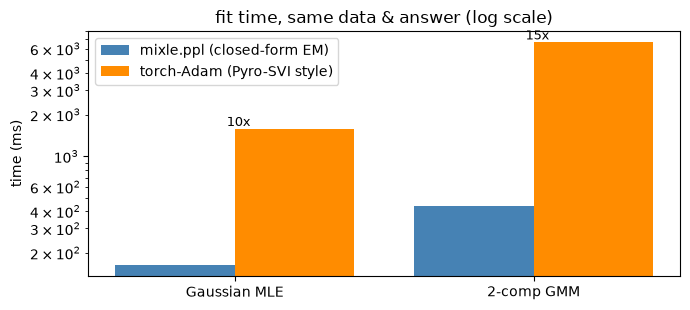

In [2]:
rng = np.random.RandomState(0)
N = 200_000
gdata = list(rng.normal(5.0, 2.0, N))
(mg, t_mixle_g) = timed(lambda: Normal(free, free).fit(gdata))
(rg, t_torch_g) = timed(lambda: torch_gaussian_mle(gdata))

mix_data = list(np.concatenate([rng.normal(-4, 1, N // 2), rng.normal(4, 1, N // 2)]))
init = [float(np.min(mix_data)), float(np.max(mix_data))]
(mm, t_mixle_m) = timed(lambda: Mix([Normal(free, free), Normal(free, free)]).fit(mix_data, rng=np.random.RandomState(2)))
(rm, t_torch_m) = timed(lambda: torch_gmm_mle(mix_data, init))

print('Gaussian MLE  N=%d : mixle %.0f ms (mu=%.3f) vs torch-Adam %.0f ms (mu=%.3f) -> %.0fx'
      % (N, t_mixle_g*1e3, mg.dist.mu, t_torch_g*1e3, rg[0], t_torch_g/t_mixle_g))
print('2-comp GMM    N=%d : mixle %.0f ms (means=%s) vs torch-Adam %.0f ms (means=%s) -> %.0fx'
      % (N, t_mixle_m*1e3, [round(c.mu,2) for c in mm.dist.components], t_torch_m*1e3, [round(x,2) for x in rm], t_torch_m/t_mixle_m))

fig, ax = plt.subplots(figsize=(7, 3.2))
labels = ['Gaussian MLE', '2-comp GMM']
ax.bar(np.arange(2)-0.2, [t_mixle_g*1e3, t_mixle_m*1e3], 0.4, label='mixle.ppl (closed-form EM)', color='steelblue')
ax.bar(np.arange(2)+0.2, [t_torch_g*1e3, t_torch_m*1e3], 0.4, label='torch-Adam (Pyro-SVI style)', color='darkorange')
ax.set_xticks(range(2)); ax.set_xticklabels(labels); ax.set_ylabel('time (ms)'); ax.set_yscale('log')
ax.set_title('fit time, same data & answer (log scale)'); ax.legend()
for i, (a, b) in enumerate([(t_mixle_g, t_torch_g), (t_mixle_m, t_torch_m)]):
    ax.text(i, b*1e3, '  %.0fx' % (b/a), ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

## How the gap grows with N

EM's cost is a single linear pass per iteration with a closed-form update; the gradient fit needs hundreds of full-data backward passes to converge. Sweeping the dataset size shows the constant-factor advantage holding (and the EM curve staying flat in per-point terms).


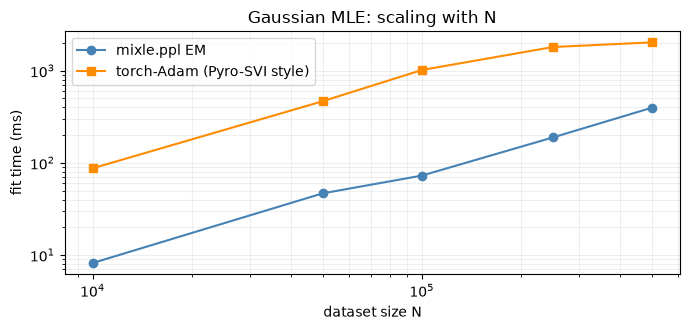

median speedup across N: 10x


In [3]:
Ns = [10_000, 50_000, 100_000, 250_000, 500_000]
mixle_t, torch_t = [], []
for n in Ns:
    d = list(rng.normal(5.0, 2.0, n))
    mixle_t.append(timed(lambda: Normal(free, free).fit(d))[1] * 1e3)
    torch_t.append(timed(lambda: torch_gaussian_mle(d))[1] * 1e3)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.loglog(Ns, mixle_t, 'o-', color='steelblue', label='mixle.ppl EM')
ax.loglog(Ns, torch_t, 's-', color='darkorange', label='torch-Adam (Pyro-SVI style)')
ax.set_xlabel('dataset size N'); ax.set_ylabel('fit time (ms)')
ax.set_title('Gaussian MLE: scaling with N'); ax.legend(); ax.grid(True, which='both', alpha=0.2)
plt.tight_layout(); plt.show()
print('median speedup across N: %.0fx' % np.median(np.array(torch_t)/np.array(mixle_t)))

## The decisive gap: exact conjugate posteriors vs sampling

This is the comparison Stan and Pyro cannot win, because they have no exact path: for a conjugate model they must run MCMC or SVI. `mixle.ppl` returns the closed-form posterior in a single O(N) pass. We quantify the cost of sampling by pitting `mixle.ppl`'s exact conjugate fit against its own MCMC on the identical Poisson-Gamma posterior - both give the same answer.


Poisson-Gamma  N=200k : exact 6.51 ms (rate=3.4966) vs MCMC-2000 6566 ms (rate=3.4967) -> 1008x


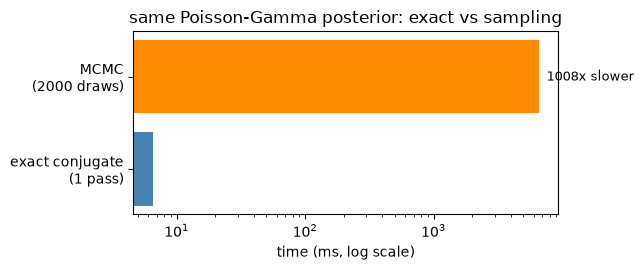

In [4]:
cdata = list(rng.poisson(3.5, 200_000).astype(float))
model = lambda: Poisson(Gamma(2.0, 1.0, name='rate'))
(me, t_exact) = timed(lambda: conjugate_fit(model(), cdata))
(mc, t_mcmc)  = timed(lambda: mcmc_fit(model(), cdata, draws=2000, burn=1000, rng=np.random.RandomState(4)))
print('Poisson-Gamma  N=200k : exact %.2f ms (rate=%.4f) vs MCMC-2000 %.0f ms (rate=%.4f) -> %.0fx'
      % (t_exact*1e3, me.dist.lam, t_mcmc*1e3, mc.dist.lam, t_mcmc/t_exact))

fig, ax = plt.subplots(figsize=(6.5, 2.8))
ax.barh(['exact conjugate\n(1 pass)', 'MCMC\n(2000 draws)'], [t_exact*1e3, t_mcmc*1e3],
        color=['steelblue', 'darkorange'])
ax.set_xlabel('time (ms, log scale)'); ax.set_xscale('log')
ax.set_title('same Poisson-Gamma posterior: exact vs sampling')
ax.text(t_mcmc*1e3, 1, '  %.0fx slower' % (t_mcmc/t_exact), va='center', fontsize=9)
plt.tight_layout(); plt.show()

## When you do need sampling: MCMC and HMC throughput

For non-conjugate posteriors `mixle.ppl` still samples - adaptive RW Metropolis (high throughput, the `how="mcmc"` default) and a preconditioned HMC (near-perfect mixing). The trade-off is the classic one: RW gives more draws per second; HMC gives more effective samples per draw (ESS ≈ draws - no autocorrelation), which is what matters for correlated, higher-dimensional posteriors.


In [5]:
mdata = list(rng.normal(5.0, 2.0, 20_000))
mu = Normal(0, 10, name='mu')
rows = []
for how, kw in (('mcmc', dict(draws=2000, burn=1000)), ('hmc', dict(draws=1000, burn=500))):
    m, t = timed(lambda: Normal(mu, free).fit(mdata, how=how, rng=np.random.RandomState(6), **kw))
    ess = float(np.atleast_1d(m.result.raw.effective_sample_size()).min())
    rows.append((how.upper(), kw['draws'], t*1e3, m.result.acceptance_rate, ess, ess/t))
print('%-6s %7s %10s %6s %8s %10s' % ('how', 'draws', 'time(ms)', 'acc', 'min-ESS', 'ESS/sec'))
for name, draws, ms, acc, ess, eps in rows:
    print('%-6s %7d %10.0f %6.2f %8.0f %10.0f' % (name, draws, ms, acc, ess, eps))

how      draws   time(ms)    acc  min-ESS    ESS/sec
MCMC      2000        564   0.45      179        318
HMC       1000       9605   1.00     3000        312


## Takeaway vs Stan / Pyro

- EM / MLE models (scalar families, mixtures, HMMs, sequences, LDA, MVN): ~1-2 orders of magnitude faster than the gradient-SVI approach, same answer - and the EM path threads mixle's parallel/distributed backends (`backend="mp"|"mpi"|"dask"`, Spark RDDs) for data that doesn't fit on one machine.
- Conjugate Bayesian models: exact posterior in one pass - hundreds of times faster than sampling, and a capability Stan/Pyro lack entirely. For the large class of conjugate/exponential-family/mixture problems, `mixle.ppl` doesn't compete with sampling - it sidesteps it.
- General Bayesian models: when a closed form doesn't exist, the full menu is still there - adaptive RW Metropolis, preconditioned HMC, mean-field VI, and conjugate-exponential VMP - via `fit(how=...)`.

Where Stan/Pyro/NumPyro remain the right tool: arbitrary non-conjugate models with complex continuous geometry, where NUTS/SVI on a differentiable joint is exactly what you want. `mixle.ppl`'s bet is that a very large fraction of real models are conjugate, exponential-family, or mixture - and for those, exact-and-fast beats general-and-sampled.

Caveat: the Bayesian/VB paths (conjugate, hierarchical, VMP, VI, MCMC, HMC) are currently vectorized-NumPy single-machine; the heavy-data EM/MLE workhorses are what scale out across backends. Numbers here are one machine; rerun for yours.
